# State-Level Response Patterns and Data Quality
### CDC BRFSS 2023

This notebook builds on the earlier BRFSS 2023 visualizations by shifting from overall distributions to state-level comparisons and data quality analysis. The goal is to explore how selected response patterns vary across states and how missing data affects interpretation.

## Why This Analysis Matters

Looking only at overall response distributions can hide important variation across states. In addition, large amounts of missing data can make public health patterns harder to interpret.

This notebook focuses on:
- comparing selected response patterns across states
- identifying where missing data is highest
- examining how data quality affects interpretation
- moving from simple description to deeper comparison

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Load the Dataset
BRFSS2023_df = pd.read_csv(r"C:\Users\alin2\Downloads\BRFSS2023.csv")

BRFSS2023_df.head()

,_state,fmonth,idate,imonth,iday,iyear,dispcode,seqno,_psu,ctelenm1,...,drocdy4_,_rfbing6,_drnkwk2,_rfdrhv8,_flshot7,_pneumo3,_aidtst4,_rfseat2,_rfseat3,_drnkdrv
0,1,1,3012023,3,1,2023,1100,2023000001,2023000001,1.0,...,0,1,0,1,2.0,2.0,2.0,1,1,9
1,1,1,1062023,1,6,2023,1100,2023000002,2023000002,1.0,...,0,1,0,1,1.0,1.0,2.0,1,1,9
2,1,1,3082023,3,8,2023,1100,2023000003,2023000003,1.0,...,0,1,0,1,1.0,1.0,2.0,1,1,9
3,1,1,3062023,3,6,2023,1100,2023000004,2023000004,1.0,...,0,1,0,1,1.0,1.0,1.0,1,1,9
4,1,1,1062023,1,6,2023,1100,2023000005,2023000005,1.0,...,7,1,47,1,2.0,1.0,2.0,1,1,2


In [4]:
#Dataset Overview
print("Dataset shape:")
print(BRFSS2023_df.shape)

Dataset shape:
(433323, 350)


In [5]:
BRFSS2023_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 433323 entries, 0 to 433322
Columns: 350 entries, _state to _drnkdrv
dtypes: float64(294), int64(56)
memory usage: 1.1 GB


In [6]:
# Select Variables for Analysis

analysis_df = BRFSS2023_df[['_state', '_drnkdrv', '_pneumo3']].copy()

analysis_df.head()

,_state,_drnkdrv,_pneumo3
0,1,9,2.0
1,1,9,1.0
2,1,9,1.0
3,1,9,1.0
4,1,2,1.0


In [7]:
# Basic Data Cleaning

analysis_df['_drnkdrv'] = pd.to_numeric(analysis_df['_drnkdrv'], errors='coerce')
analysis_df['_pneumo3'] = pd.to_numeric(analysis_df['_pneumo3'], errors='coerce')
analysis_df['_state'] = pd.to_numeric(analysis_df['_state'], errors='coerce')

In [8]:
# Missing Data Overview

missing_percent = analysis_df.isna().mean() * 100
missing_percent

_state       0.000000
_drnkdrv     0.000000
_pneumo3    60.578368
dtype: float64

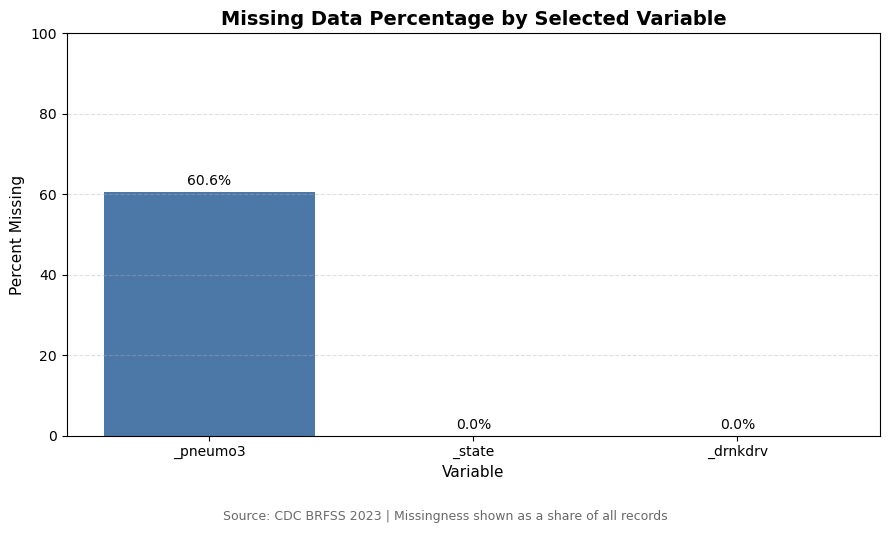

In [ ]:
#Missing data chart

missing_percent = analysis_df.isna().mean().sort_values(ascending=False) * 100

plt.figure(figsize=(9, 5))
bars = plt.bar(
    missing_percent.index,
    missing_percent.values,
    color=['#4C78A8', '#F58518', '#54A24B']
)

plt.title("Missing Data Percentage by Selected Variable", fontsize=14, weight='bold')
plt.xlabel("Variable", fontsize=11)
plt.ylabel("Percent Missing", fontsize=11)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=0)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.1f}%",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.figtext(
    0.5, -0.05,
    "Source: CDC BRFSS 2023 | Missingness shown as a share of all records",
    ha='center',
    fontsize=9,
    color='dimgray'
)

plt.tight_layout()
plt.show()

### Interpretation

The missing data chart reveals a striking imbalance across the selected variables. While both the state identifier (`_state`) and the drinking-and-driving variable (`_drnkdrv`) contain complete observations, the pneumococcal vaccination variable (`_pneumo3`) shows a very high level of missing responses, exceeding 60% of the dataset.

This level of missingness is analytically important because it limits how confidently vaccination patterns can be interpreted. When a majority of records lack valid responses, the observed distribution may not accurately represent the true population behavior. Rather than ignoring this issue, the analysis explicitly highlights missing data as part of the story. Transparent reporting of data completeness helps prevent misleading conclusions and supports responsible public-health interpretation.

In [ ]:
# Drinking and driving response distribution

state_drnkdrv = pd.crosstab(
    analysis_df['_state'],
    analysis_df['_drnkdrv'],
    normalize='index'
) * 100

state_drnkdrv.head(10)

_drnkdrv,1,2,9
_state,,,
1,1.398441,38.743696,59.857863
2,1.447964,49.628959,48.923077
4,1.021934,46.709870,52.268195
5,0.766212,36.254906,62.978882
6,1.227455,46.025384,52.747161
8,1.742002,56.153934,42.104065
9,1.589306,53.689085,44.721608
10,1.214386,47.921532,50.864082
11,1.808544,57.249766,40.941690


In [13]:
drnkdrv_labels = {
    1.0: "Category 1",
    2.0: "Category 2",
    9.0: "Category 9"
}

analysis_df['drnkdrv_label'] = analysis_df['_drnkdrv'].map(drnkdrv_labels)
analysis_df['drnkdrv_label'] = analysis_df['drnkdrv_label'].fillna("Missing")

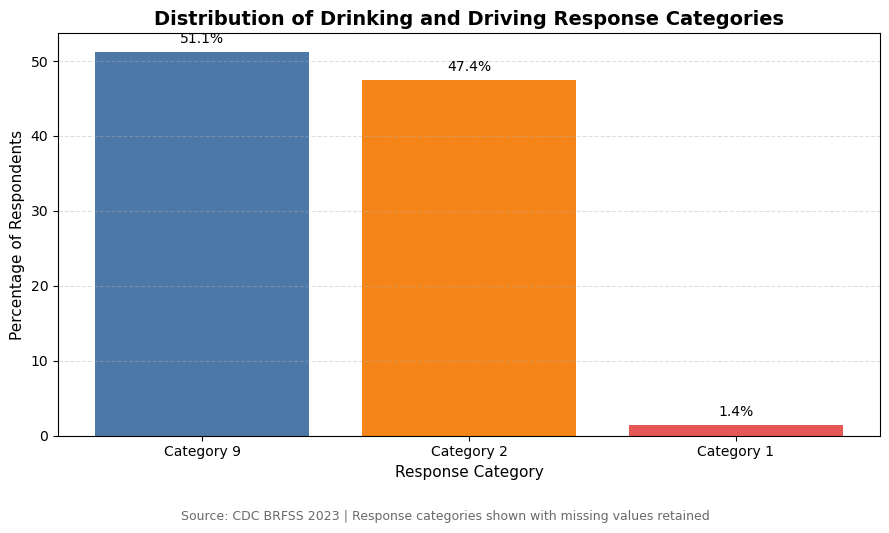

In [14]:
drnkdrv_percent = (
    analysis_df['drnkdrv_label']
    .value_counts(normalize=True)
    .mul(100)
)

plt.figure(figsize=(9, 5))
bars = plt.bar(
    drnkdrv_percent.index,
    drnkdrv_percent.values,
    color=['#4C78A8', '#F58518', '#E45756', '#B0B0B0']
)

plt.title("Distribution of Drinking and Driving Response Categories", fontsize=14, weight='bold')
plt.xlabel("Response Category", fontsize=11)
plt.ylabel("Percentage of Respondents", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.8,
        f"{height:.1f}%",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.figtext(
    0.5, -0.05,
    "Source: CDC BRFSS 2023 | Response categories shown with missing values retained",
    ha='center',
    fontsize=9,
    color='dimgray'
)

plt.tight_layout()
plt.show()

### Interpretation

The distribution of drinking-and-driving response categories shows that the dataset is highly concentrated in two categories, with Category 9 and Category 2 representing the vast majority of responses. In contrast, Category 1 appears only rarely within the dataset.

Such concentration suggests that the behavior or reporting pattern represented by Category 1 is relatively uncommon among respondents. At the same time, the dominance of the other two categories indicates that the survey responses cluster strongly around a limited set of outcomes. This uneven distribution highlights the importance of looking beyond simple averages and instead examining how response categories are proportionally represented within the data.

In [15]:
# Top 10 states with highest missing pneumococcal responses

missing_pneumo_by_state = (
    analysis_df['_pneumo3']
    .isna()
    .groupby(analysis_df['_state'])
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .head(10)
)

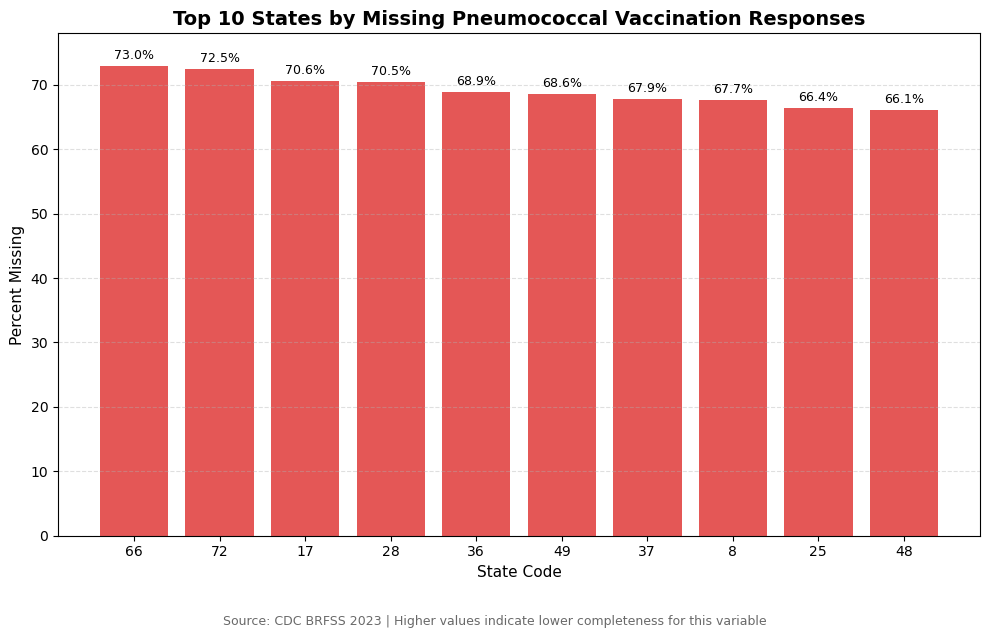

In [16]:
plt.figure(figsize=(10, 6))
bars = plt.bar(
    missing_pneumo_by_state.index.astype(str),
    missing_pneumo_by_state.values,
    color='#E45756'
)

plt.title("Top 10 States by Missing Pneumococcal Vaccination Responses", fontsize=14, weight='bold')
plt.xlabel("State Code", fontsize=11)
plt.ylabel("Percent Missing", fontsize=11)
plt.ylim(0, max(missing_pneumo_by_state.values) + 5)
plt.grid(axis='y', linestyle='--', alpha=0.4)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.6,
        f"{height:.1f}%",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.figtext(
    0.5, -0.05,
    "Source: CDC BRFSS 2023 | Higher values indicate lower completeness for this variable",
    ha='center',
    fontsize=9,
    color='dimgray'
)

plt.tight_layout()
plt.show()

### Interpretation

The chart identifies the states with the highest levels of missing responses for the pneumococcal vaccination variable. Missingness exceeds 65% in each of the top ten states, with several states approaching or exceeding 70%.

This pattern suggests that incomplete responses are not randomly distributed across the dataset. Instead, certain states appear to have systematically higher levels of missing data. Such variation may reflect differences in survey participation, reporting practices, or respondent awareness. Regardless of the underlying cause, these differences highlight an important analytical challenge: when missing data varies across geographic regions, state-level comparisons must be interpreted cautiously because the underlying information may not be equally complete.

In [17]:
# drinking and driving responses by state

state_drnkdrv = pd.crosstab(
    analysis_df['_state'],
    analysis_df['drnkdrv_label'],
    normalize='index'
) * 100

selected_states = state_drnkdrv.head(10)

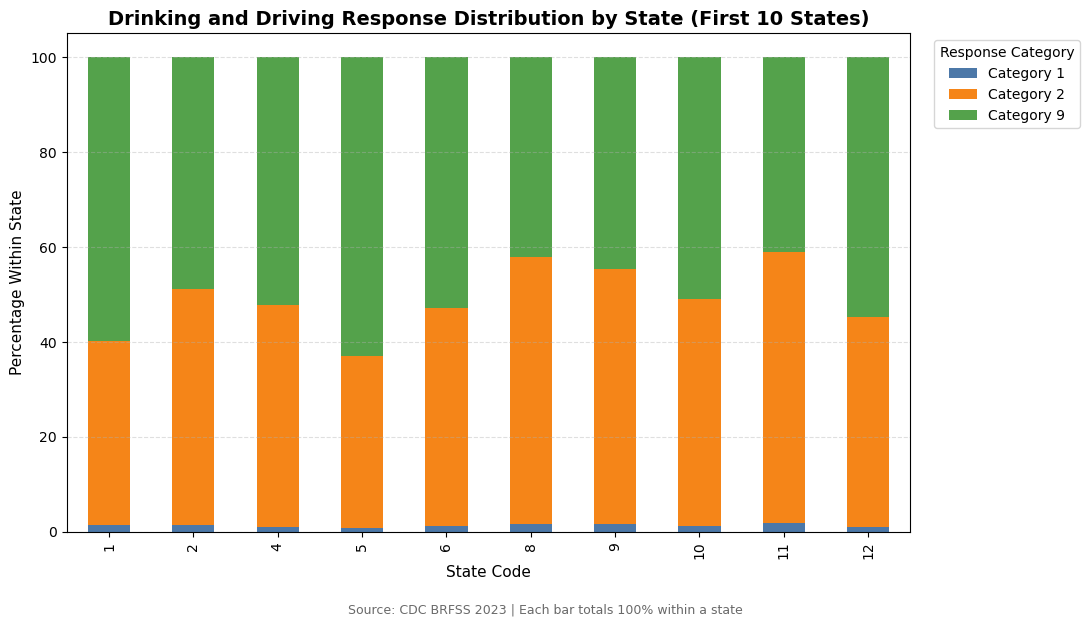

In [18]:
ax = selected_states.plot(
    kind='bar',
    stacked=True,
    figsize=(11, 6),
    color=['#4C78A8', '#F58518', '#54A24B', '#B0B0B0']
)

ax.set_title("Drinking and Driving Response Distribution by State (First 10 States)", fontsize=14, weight='bold')
ax.set_xlabel("State Code", fontsize=11)
ax.set_ylabel("Percentage Within State", fontsize=11)
ax.legend(title="Response Category", bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.figtext(
    0.5, -0.03,
    "Source: CDC BRFSS 2023 | Each bar totals 100% within a state",
    ha='center',
    fontsize=9,
    color='dimgray'
)

plt.tight_layout()
plt.show()

### Interpretation

The stacked bar chart reveals how drinking-and-driving response categories vary across states. Each bar represents a single state, and the colored segments show the percentage of respondents within that state who fall into each response category.

Although the overall dataset is dominated by Categories 2 and 9, the chart shows that the relative proportions of these categories differ across states. Some states exhibit a larger share of Category 2 responses, while others show a stronger concentration in Category 9. These differences illustrate how response distributions can vary geographically, emphasizing the value of examining state-level patterns rather than relying solely on national aggregates.

In [19]:
# pneumococcal vaccination response by state

pneumo_labels = {
    1.0: "Yes",
    2.0: "No"
}

analysis_df['pneumo_label'] = analysis_df['_pneumo3'].map(pneumo_labels)
analysis_df['pneumo_label'] = analysis_df['pneumo_label'].fillna("Missing")

In [21]:
state_pneumo = pd.crosstab(
    analysis_df['_state'],
    analysis_df['pneumo_label'],
    normalize='index'
) * 100

selected_pneumo_states = state_pneumo.head(10)

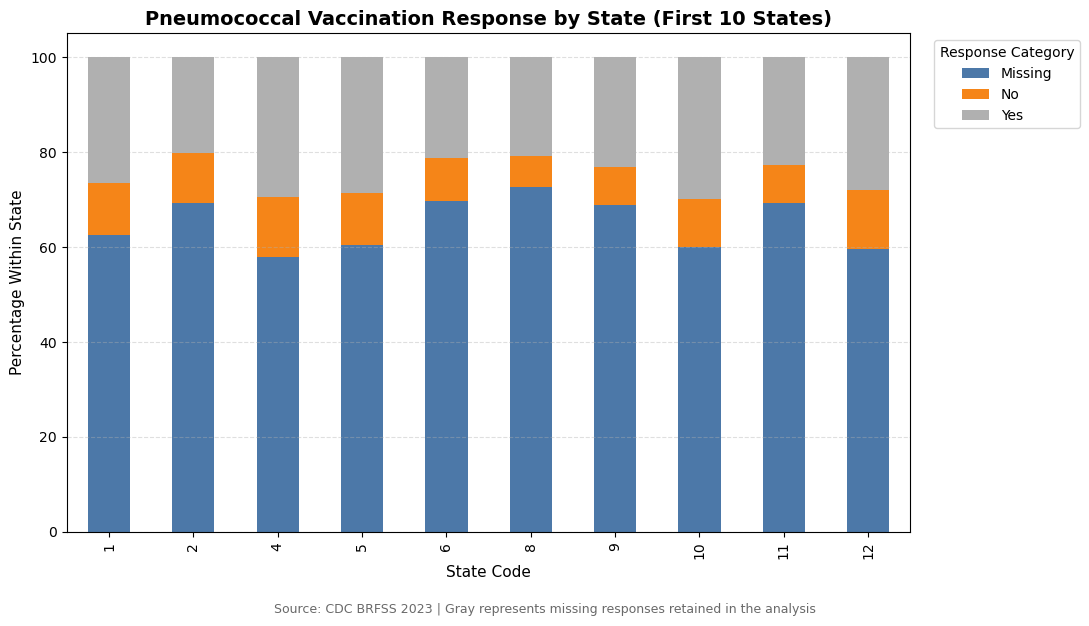

In [22]:
ax = selected_pneumo_states.plot(
    kind='bar',
    stacked=True,
    figsize=(11, 6),
    color=['#4C78A8', '#F58518', '#B0B0B0']
)

ax.set_title("Pneumococcal Vaccination Response by State (First 10 States)", fontsize=14, weight='bold')
ax.set_xlabel("State Code", fontsize=11)
ax.set_ylabel("Percentage Within State", fontsize=11)
ax.legend(title="Response Category", bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.figtext(
    0.5, -0.03,
    "Source: CDC BRFSS 2023 | Gray represents missing responses retained in the analysis",
    ha='center',
    fontsize=9,
    color='dimgray'
)

plt.tight_layout()
plt.show()

### Interpretation

This visualization compares pneumococcal vaccination response patterns across states. The stacked structure allows the viewer to see how the proportions of "Yes," "No," and missing responses differ within each state.

Across all states shown, missing responses represent the largest portion of the data. While the shares of "Yes" and "No" responses vary moderately between states, the dominant presence of missing data remains consistent. This reinforces the earlier finding that incomplete responses are a defining feature of this variable. The high level of missingness limits the ability to draw strong conclusions about vaccination behavior and highlights the importance of evaluating data completeness before interpreting public-health trends.

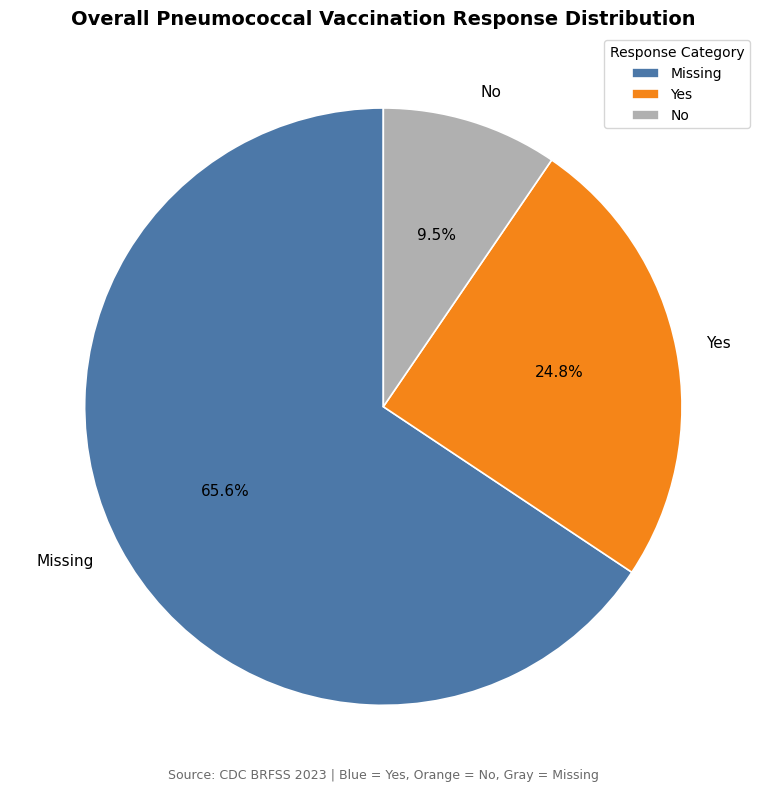

In [23]:
# Polished pie chart for pneumococcal response

pneumo_counts = analysis_df['pneumo_label'].value_counts()
colors = ['#4C78A8', '#F58518', '#B0B0B0']

plt.figure(figsize=(8, 8))

wedges, texts, autotexts = plt.pie(
    pneumo_counts,
    labels=pneumo_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
    textprops={'fontsize': 11}
)

plt.title("Overall Pneumococcal Vaccination Response Distribution", fontsize=14, weight='bold')

plt.legend(
    wedges,
    pneumo_counts.index,
    title="Response Category",
    loc="best"
)

plt.figtext(
    0.5, 0.02,
    "Source: CDC BRFSS 2023 | Blue = Yes, Orange = No, Gray = Missing",
    ha='center',
    fontsize=9,
    color='dimgray'
)

plt.tight_layout()
plt.show()

### Interpretation

The pie chart summarizes the overall distribution of pneumococcal vaccination responses in the dataset. The largest segment corresponds to missing responses, which account for nearly two-thirds of all records. Among the remaining responses, the proportion of individuals reporting vaccination ("Yes") is noticeably larger than those reporting "No."

The dominance of missing data is the most significant feature of this chart. When such a large share of records lacks valid responses, any conclusions about vaccination prevalence must be treated cautiously. The chart therefore serves not only as a descriptive summary but also as a reminder that data completeness plays a critical role in shaping the reliability of analytical insights.

## Conclusion

This notebook shows that response patterns in BRFSS 2023 vary across variables and across states, while missing data remains a major limitation, especially for pneumococcal vaccination responses. Overall, the analysis highlights the importance of combining visual clarity with careful interpretation when working with public health survey data.